In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

EVENT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "events"
    / "Auger_081847956000.json"
)

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

if not EVENT_PATH.exists():
    raise FileNotFoundError(f"Event file not found: {EVENT_PATH}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Event file: {EVENT_PATH}")

Project root: /home/abdul_samad/projects/auger-direction-reconstruction
Event file: /home/abdul_samad/projects/auger-direction-reconstruction/data/raw/events/Auger_081847956000.json


In [3]:
with EVENT_PATH.open("r", encoding = "utf-8") as file:
    event = json.load(file)

print("Top-level sections")
print(list(event.keys()))

print(f"\nEvent ID: {event['info']['id']}")
print(f"Triggered stations: {len(event['stations'])}")

Top-level sections
['meta', 'info', 'flags', 'fdrec', 'eyes', 'sdrec', 'stations']

Event ID: 81847956000
Triggered stations: 28


In [4]:
SAFE_STATION_FIELDS = [
    "id",
    "name",
    "x",
    "y",
    "z",
    "t",
    "dt",
    "signal",
    "dsignal",
    "sat",
    "isSelected"
]

all_station_data = pd.DataFrame(event['stations'])

missing_fields = [
    field
    for field in SAFE_STATION_FIELDS
    if field not in all_station_data.columns
]

if missing_fields:
    raise KeyError(f"Missing fields in station data: {missing_fields}")

stations = all_station_data.loc[:, SAFE_STATION_FIELDS].copy()
stations.head()

,id,name,x,y,z,t,dt,signal,dsignal,sat,isSelected
0,502,Cristalino,-4131.80,444.45,2.72,39209205,12.88,907.87,39.33,1,1
1,822,Jerrie Cobb,-5630.69,447.75,1.84,39211642,12.58,393.00,23.55,1,1
2,821,Marie Curie,-4886.17,-851.87,0.53,39213289,12.42,225.70,17.14,1,1
3,831,Stella Maris,-4876.79,1746.19,3.24,39207623,13.40,138.99,13.39,1,1
4,509,Malargue,-3375.15,1743.80,0.79,39205298,14.28,96.21,11.07,1,1


In [16]:
NUMERIC_FIELDS = [
    "x",
    "y",
    "z",
    "t",
    "dt",
    "signal",
    "dsignal",
    "sat",
    "isSelected"
]

stations[NUMERIC_FIELDS] = stations[NUMERIC_FIELDS].apply(pd.to_numeric, errors = "coerce")

if stations[NUMERIC_FIELDS].isna().any().any():
    raise ValueError("A required numerical station value is missing or invalid.")

selected_mask = stations['isSelected'].eq(1)

print(f"All triggered stations: {len(stations)}")
print(f"Selected stations: {selected_mask.sum()}")
print(f"Rejected stations: {(~selected_mask).sum()}")


stations[
    [
        "name",
        "x",
        "y",
        "t",
        "signal",
        "isSelected"
    ]
].head()

All triggered stations: 28
Selected stations: 24
Rejected stations: 4


,name,x,y,t,signal,isSelected
0,Cristalino,-4131.80,444.45,39209205,907.87,1
1,Jerrie Cobb,-5630.69,447.75,39211642,393.00,1
2,Marie Curie,-4886.17,-851.87,39213289,225.70,1
3,Stella Maris,-4876.79,1746.19,39207623,138.99,1
4,Malargue,-3375.15,1743.80,39205298,96.21,1


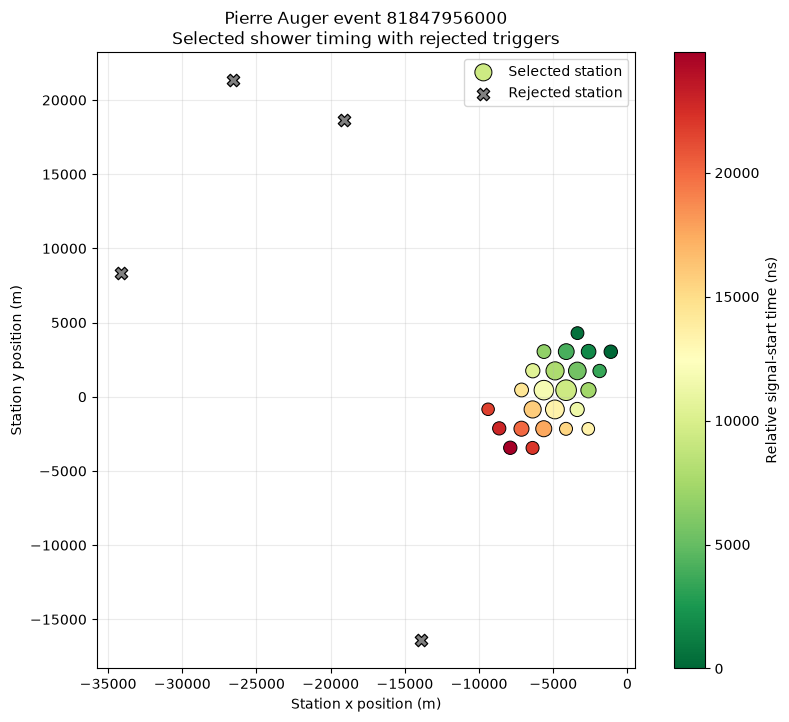

Figure saved to: /home/abdul_samad/projects/auger-direction-reconstruction/reports/figures/event_81847956000_footprint_with_rejected.png


In [19]:
selected = stations.loc[selected_mask].copy()
rejected = stations.loc[~selected_mask].copy()

if selected.empty:
    raise ValueError("This event has no selected shower stations.")

selected_reference_time = selected["t"].min()

selected["relative_time_ns"] = (
    selected["t"] - selected_reference_time
)

selected_log_signal = np.log1p(
    selected["signal"].clip(lower=0)
)

if selected_log_signal.max() > 0:
    selected["marker_size"] = (
        40
        + 180
        * selected_log_signal
        / selected_log_signal.max()
    )
else:
    selected["marker_size"] = 40.0

time_scale = Normalize(
    vmin = selected["relative_time_ns"].min(),
    vmax = selected["relative_time_ns"].max()
)

fig, ax = plt.subplots(figsize = (10,8))

selected_plot = ax.scatter(
    selected["x"],
    selected["y"],
    c = selected["relative_time_ns"],
    s = selected["marker_size"],
    cmap = "RdYlGn_r",
    norm = time_scale,
    marker = "o",
    edgecolor = "black",
    linewidths = 0.7,
    label = "Selected station"
)

if not rejected.empty:
    ax.scatter(
        rejected["x"],
        rejected["y"],
        s=80,
        color="gray",
        marker="X",
        edgecolors="black",
        linewidths=0.9,
        label="Rejected station",
    )

colorbar = fig.colorbar(selected_plot, ax=ax)
colorbar.set_label("Relative signal-start time (ns)")

ax.set_xlabel("Station x position (m)")
ax.set_ylabel("Station y position (m)")
ax.set_title(
    f"Pierre Auger event {event['info']['id']}\n"
    "Selected shower timing with rejected triggers"
)

ax.set_aspect("equal", adjustable="box")
ax.ticklabel_format(style="plain", useOffset=False)
ax.grid(alpha=0.25)
ax.legend()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    FIGURE_DIR
    / f"event_{event['info']['id']}_footprint_with_rejected.png"
)

fig.savefig(
    OUTPUT_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {OUTPUT_PATH}")